# EDA task

## Let's analyze some penguin data :).

### Starter code + hints.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [31]:
df = pd.read_csv("penguins.csv")

df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female


In [32]:
df_clean = df.dropna(subset=['bill_length_mm', 'flipper_length_mm']) # 
df_clean['sex'] = df_clean['sex'].fillna('Unknown')
print(df_clean.isnull().sum()) # Should be 0 for analysis columns
print(df_clean.species.value_counts()) # Check species balance: Adelie(152), Gentoo(124), Chinstrap(52)

species              0
island               0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64
species
Adelie       151
Gentoo       123
Chinstrap     68
Name: count, dtype: int64


/var/folders/g7/g4k4lcd13tgd4zgq3y8nyvv80000gn/T/ipykernel_29102/4015227362.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['sex'] = df_clean['sex'].fillna('Unknown')


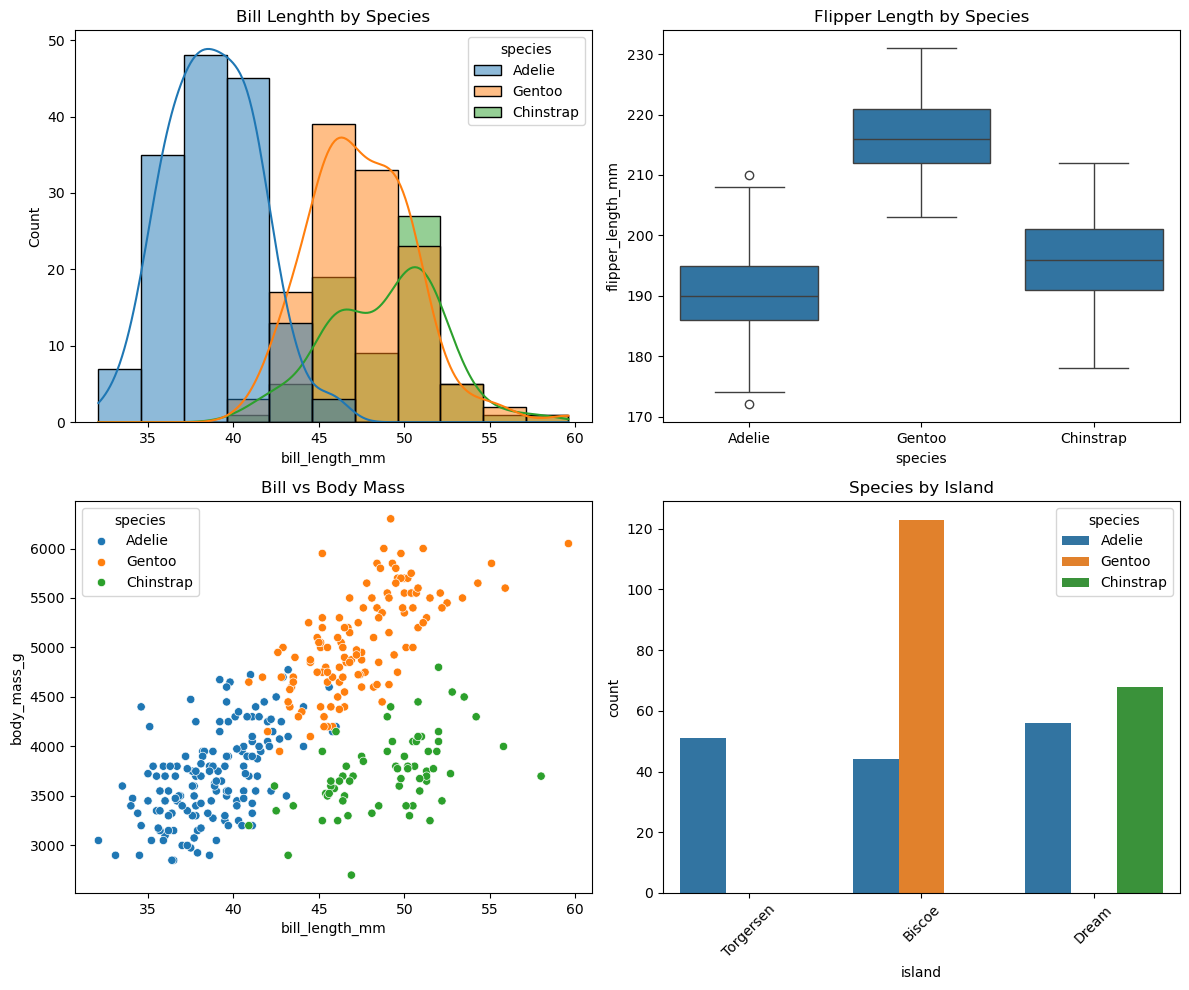

In [ ]:
# 3. Visualizations (fill in)
fig, ax = plt.subplots(2, 2, figsize=(12,10))

# A) Histogram with KDE
sns.histplot(data=df_clean, x="bill_length_mm", hue="species", kde=True, ax=ax[0, 0])
ax[0,0].set_title("Bill Lenghth by Species")

# B) Boxplot
sns.boxplot(data=df_clean, x='species', y='flipper_length_mm',
ax=ax[0,1])
ax[0,1].set_title('Flipper Length by Species')

# C) Scatterplot
sns.scatterplot(data=df_clean, x='bill_length_mm',
y='body_mass_g', hue='species', ax=ax[1,0])
ax[1,0].set_title('Bill vs Body Mass')

# D) Countplot
sns.countplot(data=df_clean, x='island', hue='species',
ax=ax[1,1])
ax[1,1].set_title('Species by Island') # Rotate if overlapping:
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

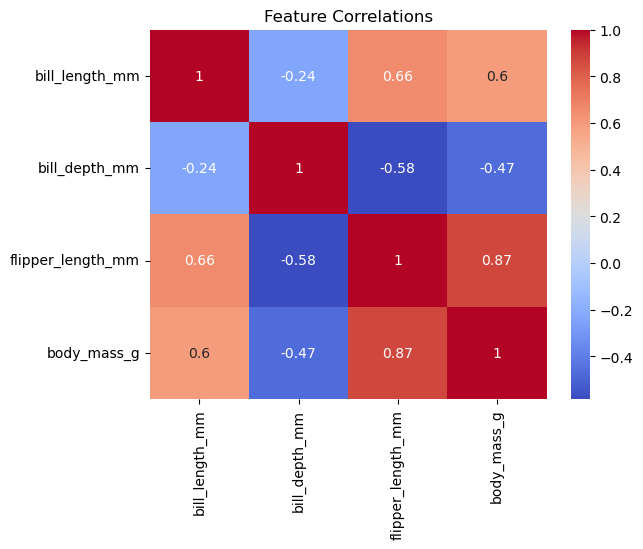

In [12]:
corr = df_clean[['bill_length_mm','bill_depth_mm','flipper_length_mm', 'body_mass_g']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Feature Correlations')
plt.show()

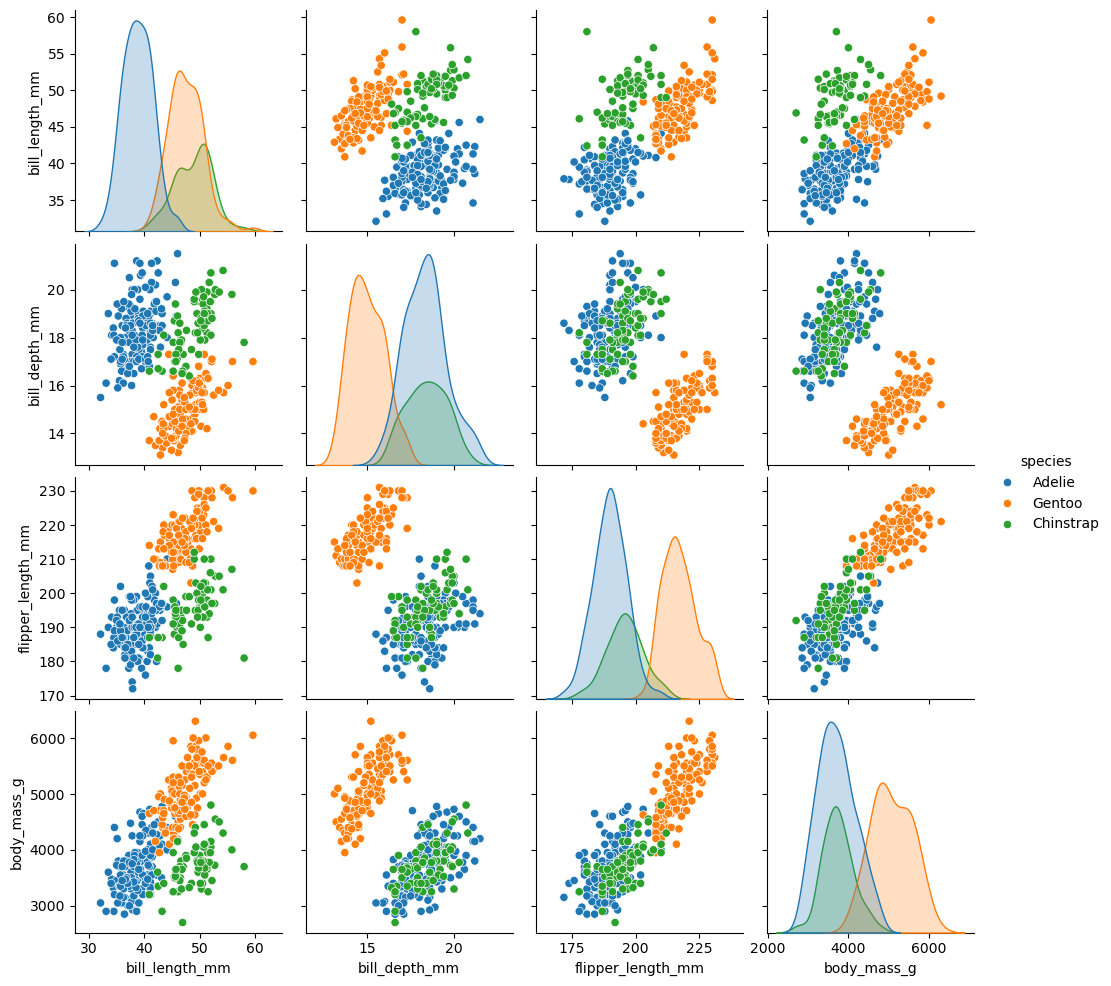

In [118]:
sns.pairplot(df_clean, hue="species")

### Observations and implications

**Insight 1:** based on the 4th graphic, we can conclude that the Adelie species can be found in every island in the dataset. <br>
**Insight 2:** based on the 2th graphic, the Gentoo species has overall a bigger flipper length and weight. <br>
**Insight 3:** based on the 1st and 2nd graphics, Adelie species have the smallest bill and flipper lengths.<br>
**Bonus insight:** based on the feature correlations graphic, we can assume that the flipper length has a positive impact on body mass.

# EDA Task

## Let's analyze some penguin data!

In [119]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("penguins.csv")

df.head() 

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female


In [120]:
# Let's clean the data first

df_i1 = df.dropna(subset=["bill_length_mm", "flipper_length_mm", "sex", "species"])
print(df_i1.isnull().sum()) # Should be 0 for analysis columns

species              0
island               0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64


## Insights

Text(0.5, 1.0, 'Population by species')

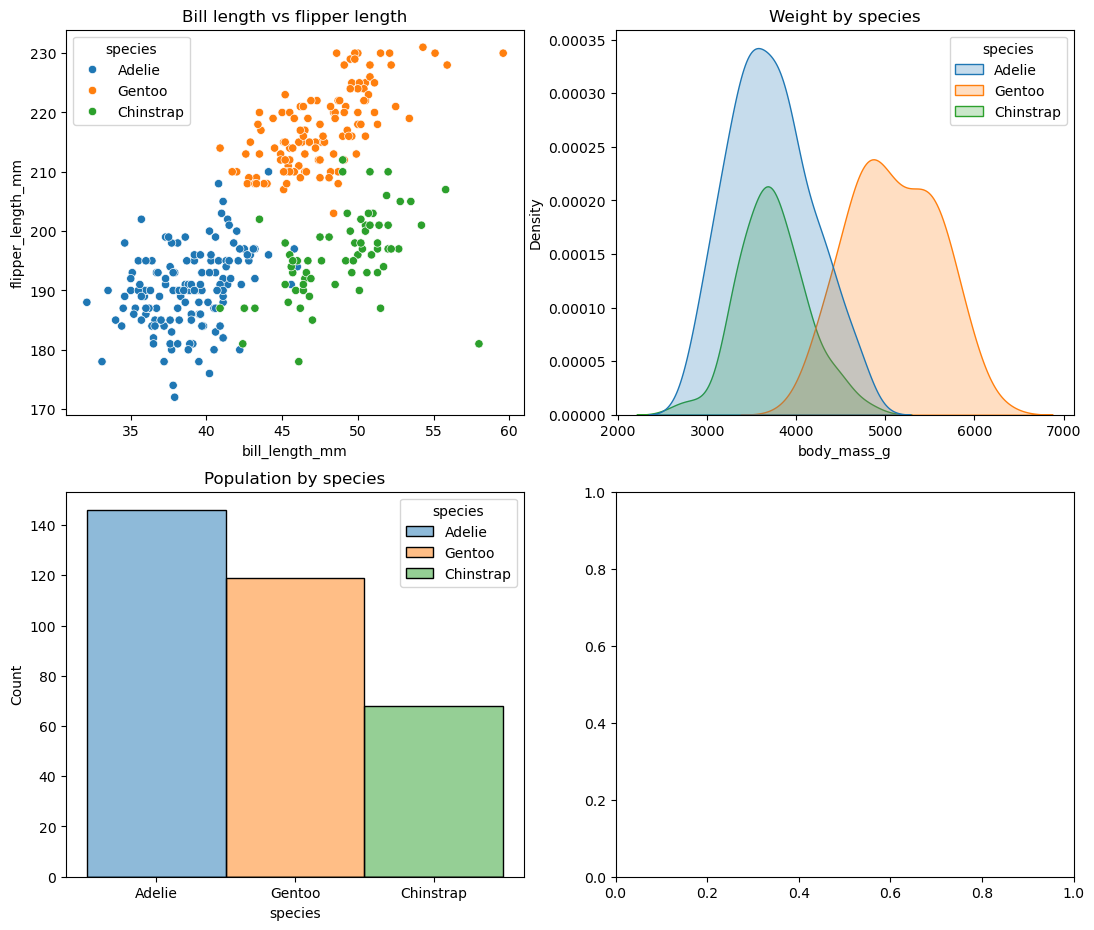

In [121]:
fig, ax = plt.subplots(2, 2, figsize=(13,11))

# Bill length and flipper length by species insight 
sns.scatterplot(data=df_i1, x="bill_length_mm", y="flipper_length_mm", hue="species", ax=ax[0,0])
ax[0,0].set_title("Bill length vs flipper length")

# Weight by species 
sns.kdeplot(data=df_i1, x="body_mass_g", hue="species", fill=True, ax=ax[0,1])
ax[0,1].set_title("Weight by species")

# Population by species
sns.histplot(data=df_i1, x="species", hue="species", ax=ax[1,0])
ax[1,0].set_title("Population by species")